In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import tqdm
import os

from PSN.psn import psn

import os
from tqdm import tqdm
import glob
import re

import math
import numpy as np
import scipy
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import r2_score

import imageio.v2 as imageio
import torch
import torch.nn.functional as F
from torchvision import transforms

from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor

# Set random seed for reproducibility
np.random.seed(42)

/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# helper functions for computing reliability over time

In [3]:
def compute_noise_ceiling(data_in):
    """
    Compute the noise ceiling signal-to-noise ratio (NCSNR) and percentage noise ceiling for each channel.
    
    Parameters:
        data_in (array): Data with shape (channels, conditions, trials), where each channel has more than 1 trial per condition.
    
    Returns:
        noise_ceiling (array): Noise ceiling as a percentage for each channel.
        ncsnr (array): Noise ceiling SNR for each channel.
        signal_var (array): Signal variance for each channel.
        noise_var (array): Noise variance for each channel.
    """
    
    # Calculate noise variance as mean variance across trials for each channel
    noise_var = np.mean(np.var(data_in, axis=2, ddof=1), axis=1)
    
    # Calculate data variance as variance of the trial means across conditions for each channel
    data_var = np.var(np.mean(data_in, axis=2), axis=1, ddof=1)
    
    # Calculate signal variance by subtracting noise variance from data variance
    signal_var = np.maximum(data_var - noise_var / data_in.shape[2], 0)  # Ensure non-negative variance
    
    # Compute noise ceiling SNR
    ncsnr = np.sqrt(signal_var) / np.sqrt(noise_var)
    
    # Calculate noise ceiling as percentage based on SNR
    noise_ceiling = 100 * (ncsnr ** 2 / (ncsnr ** 2 + 1 / data_in.shape[2]))
    
    return noise_ceiling, ncsnr, signal_var, noise_var


def compute_ncsnr_all_timepoints(data_4d, times):
    """
    Compute NCSNR and NC percentage for every channel at every timepoint.
    
    Parameters:
        data_4d (array): Data with shape (conditions, channels, trials, timepoints)
        times (array): Time array in milliseconds
    
    Returns:
        ncsnr_results (array): NCSNR for each channel and timepoint (channels, timepoints)
        nc_results (array): Noise ceiling percentage for each channel and timepoint (channels, timepoints)
    """
    
    n_conditions, n_channels, n_trials, n_timepoints = data_4d.shape
    
    # Initialize result arrays
    ncsnr_results = np.zeros((n_channels, n_timepoints))
    nc_results = np.zeros((n_channels, n_timepoints))
    
    print(f"Computing NCSNR for {n_channels} channels across {n_timepoints} timepoints...")
    
    # Iterate through each timepoint
    for t in range(n_timepoints):
        if t % 100 == 0:  # Progress indicator
            print(f"Processing timepoint {t+1}/{n_timepoints} ({times[t]:.1f}ms)")
        
        # Extract data for this timepoint: (conditions, channels, trials)
        timepoint_data = data_4d[:, :, :, t]  # (conditions, channels, trials)
        
        # Transpose to (channels, conditions, trials) for compute_noise_ceiling
        reshaped_data = timepoint_data.transpose(1, 0, 2)  # (channels, conditions, trials)
        
        # Compute noise ceiling for this timepoint
        noise_ceiling, ncsnr, _, _ = compute_noise_ceiling(reshaped_data)
        
        # Store results
        ncsnr_results[:, t] = ncsnr
        nc_results[:, t] = noise_ceiling
    
    print("NCSNR computation complete!")
    return ncsnr_results, nc_results


def ncsnr_figs(ncsnr_all, nc_all, times):

    print(f"NCSNR results shape: {ncsnr_all.shape}") 
    print(f"NC results shape: {nc_all.shape}")      

    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('NCSNR and Noise Ceiling Analysis Across All Timepoints', fontsize=16)

    # 1. NCSNR heatmap: channels × time
    im1 = axes[0,0].imshow(ncsnr_all, aspect='auto', cmap='viridis', 
                        extent=[times[0], times[-1], nc_all.shape[0], 1], interpolation='none')
    axes[0,0].set_title('NCSNR Heatmap (Channels × Time)')
    axes[0,0].set_xlabel('Time (s)')
    axes[0,0].set_ylabel('Channel')
    axes[0,0].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    plt.colorbar(im1, ax=axes[0, 0], label='NCSNR')

    # 2. Noise Ceiling heatmap: channels × time
    im2 = axes[0, 1].imshow(nc_all, aspect='auto', cmap='plasma', 
                        extent=[times[0], times[-1], nc_all.shape[0], 1], interpolation='none')
    axes[0, 1].set_title('Noise Ceiling % Heatmap (Channels × Time)')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Channel')
    axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    plt.colorbar(im2, ax=axes[0, 1], label='Noise Ceiling %')

    # 3. Mean NCSNR across channels vs time
    mean_ncsnr_time = np.mean(ncsnr_all, axis=0)
    axes[1,0].plot(times, mean_ncsnr_time, 'b-', linewidth=2)
    axes[1,0].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    axes[1,0].set_title('Mean NCSNR Across Channels vs Time')
    axes[1,0].set_xlabel('Time (s)')
    axes[1,0].set_ylabel('Mean NCSNR')
    axes[1,0].grid(True, alpha=0.3)

    # 4. Mean Noise Ceiling across channels vs time
    mean_nc_time = np.mean(nc_all, axis=0)
    axes[1, 1].plot(times, mean_nc_time, 'r-', linewidth=2)
    axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    axes[1, 1].set_title('Mean Noise Ceiling % Across Channels vs Time')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Mean Noise Ceiling %')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"Mean NCSNR across all channels and time: {np.mean(ncsnr_all):.3f}")
    print(f"Max NCSNR: {np.nanmax(ncsnr_all):.3f}")
    print(f"Mean Noise Ceiling across all channels and time: {np.mean(nc_all):.1f}%")
    print(f"Max Noise Ceiling: {np.nanmax(nc_all):.1f}%")

    # Find peak times
    peak_ncsnr_time_idx = np.argmax(mean_ncsnr_time)
    peak_nc_time_idx = np.argmax(mean_nc_time)
    print(f"Peak NCSNR time: {times[peak_ncsnr_time_idx]:.1f}ms")
    print(f"Peak NC time: {times[peak_nc_time_idx]:.1f}ms")
    

# load data from a subject

In [4]:
base_dir = '/home/ri99/ieeg'
ieeg_dir = f'{base_dir}/subjects/111/preproc'
csv_dir = f'{base_dir}/nsd_PTB'
img_dir = f'{base_dir}/nsd_ecog'
cache_dir = f'{base_dir}/.cache'
os.makedirs(cache_dir, exist_ok=True)
sub = 11
n_blocks = -1
n_runs = 56

In [5]:
curric = pd.read_csv(f"{csv_dir}/curriculum_patient{sub}.csv")
# labels = metapath_df['Destrieux_label_text'].values
curric

,Unnamed: 0,filename,inventory,coco_id,is_repeat,repetition_number,block
0,0,special_23715.png,1x-shared1000_A,23715.0,0,1,1
1,1,notspecial_24264.png,1x-shared1000_A,24264.0,0,1,1
2,2,pair_45_w_pagoda1.png,MST,NaN,0,1,1
3,3,pair_33_nsd_777_1_cocoid_68844.png,MST,68844.0,0,1,1
4,4,notspecial_36682.png,3x-shared1000_A,36682.0,0,1,1
...,...,...,...,...,...,...,...
5595,5595,unchosen_3430_cocoid_10456.png,filler,10456.0,1,2,filler_block_2
5596,5596,unchosen_794_cocoid_30369.png,filler,30369.0,1,2,filler_block_2
5597,5597,unchosen_290_cocoid_65433.png,filler,65433.0,1,2,filler_block_2
5598,5598,unchosen_2110_cocoid_38496.png,filler,38496.0,1,2,filler_block_2


In [6]:
if n_blocks == -1:  # use all available blocks
    block_list = curric['block'].unique().astype(str)
else:  # use n_blocks to specify instead
    block_list = [str(x) for x in range(1, n_blocks+1)]

print(block_list)
image_names = list(curric[curric['block'].isin(block_list)]['filename'])
print(len(image_names))

['1' '2' '3' '4' 'filler_block_1' 'filler_block_2']
5600


In [7]:
imsize = (224,224)
resize_transform = transforms.Resize(imsize)
data_type = torch.float32

images = torch.empty((len(image_names), 3, imsize[0], imsize[1]), dtype=data_type)

assert len(image_names) == len(curric['block'])

In [8]:
# for i, im_name in tqdm(enumerate(image_names), total=len(image_names)):
#     default_path = f"{img_dir}/stimulusfiles/{im_name}"
#     if not os.path.exists(default_path):  # non-default case; image isn't in stimulusfiles
#         candidates = glob.glob(f"{img_dir}/**/{im_name}", recursive=True)
    
#         if len(candidates) == 0:
#             raise FileNotFoundError(f"No matching files found for {im_name} under {img_dir}")
    
#         imgs = [imageio.imread(path) for path in candidates]
    
#         # check for identical matches
#         if len(imgs) > 1:
#             for j in range(1, len(imgs)):
#                 if not np.array_equal(imgs[0], imgs[j]):
#                     raise ValueError(f"Non-identical duplicates found for {im_name}:\n{candidates}")
    
#         im = imgs[0]
#     else:  # default case; image in stimulusfiles
#         im = imageio.imread(default_path)

#     if im.ndim == 2:
#         im = np.stack([im]*3, axis=-1)
#     elif im.shape[2] == 4:
#         im = im[:, :, :3]
#     im = torch.tensor(im, dtype=data_type).permute(2,0,1)
#     im = resize_transform(im)
#     images[i] = im

# print(images.shape, type(images), images.dtype)
# print(images.min(), images.max())

In [9]:
run_list = list(range(1, n_runs+1))

all_data = []
all_labels = []
time_ref = None

for run in tqdm(run_list):
    data = np.load(f"{ieeg_dir}/data/NSD_sub1{sub}_run{run}_data.npy")
    labels = pd.read_csv(f"{ieeg_dir}/labels/NSD_sub1{sub}_run{run}_labels.csv")
    time = np.load(f"{ieeg_dir}/time/NSD_sub1{sub}_run{run}_time.npy")

    assert time.shape[0] == data.shape[2], f"time mismatch in run {run}"
    assert labels.shape[0] == data.shape[1], f"label mismatch in run {run}"

    assert labels['channel_name'].iloc[168] == 'ECG1'
    
    if time_ref is None:
        time_ref = time
    else:
        assert np.allclose(time, time_ref), f"time array differs in run {run}"

    all_data.append(data)
    all_labels.append(labels)

# stack along the trial axis (axis=0)
data = np.concatenate(all_data, axis=0)
labels = pd.concat(all_labels, ignore_index=True)
time = time_ref

print(f"ieeg_data shape: {data.shape}")
print(f"ieeg_labels shape: {labels.shape}")
print(f"ieeg_time shape: {time.shape}")

print('dropping all channels including and after ECG1')
labels = labels.iloc[:168]
data = data[:, :168]

# reshape data to channels x timepoints x images
data = data.transpose(1, 2, 0).astype(np.float32)

print('dropping timepoints')
data = data[:, ::2]
time = time[::2]

print(f"data shape: {data.shape}")
print(f"labels shape: {labels.shape}")
print(f"time shape: {time.shape}")

100%|██████████| 56/56 [00:12<00:00,  4.63it/s]


ieeg_data shape: (5600, 276, 564)
ieeg_labels shape: (15456, 2)
ieeg_time shape: (564,)
dropping all channels including and after ECG1
dropping timepoints
data shape: (168, 282, 5600)
labels shape: (168, 2)
time shape: (282,)


In [10]:
if images.shape[0] != data.shape[2]:
    pass
    # images = images[:ieeg_data.shape[0]]
    # print("Dropped images based on available data.")
    # print(f"New images shape: {images.shape}")

assert images.shape[0] == data.shape[2]

In [11]:
data.shape

(168, 282, 5600)

# reshape to identify repeated stimuli

In [12]:
def extract_coco_id(filepath):
    """Extract COCO ID from filepath like /path/to/_nsd59080_.png -> nsd59080"""
    match = re.search(r'(\d+)_', filepath)
    return f"nsd{match.group(1)}" if match else filepath

In [13]:
def reshape_electrode_data_by_stimuli(electrode_data, events_df, stim_column='stim_file', extract_fn=extract_coco_id):
    """
    Reshape electrode data from (channels, time, trials) to (channels, images, time, repeats)
    based on repeated stimuli in events dataframe.
    
    Parameters:
        electrode_data: array of shape (channels, time, trials) 
        events_df: DataFrame with stimulus information
        stim_column: column name containing stimulus identifiers
    
    Returns:
        reshaped_data: array of shape (channels, n_unique_images, time, max_repeats)
        stimulus_info: dict with stimulus mapping information
    """
    import re
    
    print(f"Original electrode data shape: {electrode_data.shape}")
    print(f"Events dataframe shape: {events_df.shape}")
    
    # Extract NSD ID from the stimulus file path (e.g., _nsd59080_)
    events_df_copy = events_df.copy()
    
    events_df_copy['nsd_id'] = events_df_copy[stim_column].apply(extract_fn)
    
    # Get stimulus repetition information based on NSD ID only
    stim_counts = events_df_copy['nsd_id'].value_counts()
    unique_stimuli = stim_counts.index.tolist()
    n_unique_images = len(unique_stimuli)
    max_repeats = stim_counts.max()
    
    print(f"Number of unique stimuli: {n_unique_images}")
    print(f"Maximum repetitions per stimulus: {max_repeats}")
    print(f"Repetition distribution:")
    print(stim_counts.value_counts().sort_index())
    
    # Initialize reshaped array
    n_channels, n_timepoints, n_trials = electrode_data.shape
    reshaped_data = np.full((n_channels, n_unique_images, n_timepoints, max_repeats), 
                           np.nan, dtype=electrode_data.dtype)
    
    # Create mapping from stimulus NSD ID to trial indices
    stimulus_to_trials = {}
    for trial_idx, nsd_id in enumerate(events_df_copy['nsd_id']):
        if nsd_id not in stimulus_to_trials:
            stimulus_to_trials[nsd_id] = []
        stimulus_to_trials[nsd_id].append(trial_idx)
    
    # Fill the reshaped array
    for img_idx, stimulus in enumerate(unique_stimuli):
        trial_indices = stimulus_to_trials[stimulus]
        
        # Copy data for all repetitions of this stimulus
        for repeat_idx, trial_idx in enumerate(trial_indices):
            reshaped_data[:, img_idx, :, repeat_idx] = electrode_data[:, :, trial_idx]
        
        if img_idx % 100 == 0:
            print(f"Processed {img_idx+1}/{n_unique_images} stimuli...")
    
    # Create stimulus info dictionary
    stimulus_info = {
        'unique_stimuli': unique_stimuli,
        'stimulus_counts': stim_counts.to_dict(),
        'stimulus_to_trials': stimulus_to_trials,
        'max_repeats': max_repeats,
        'n_unique_images': n_unique_images,
        'nsd_id_mapping': dict(zip(events_df_copy['nsd_id'], events_df_copy[stim_column]))
    }
    
    print(f"Final reshaped data shape: {reshaped_data.shape}")
    print(f"Shape interpretation: ({n_channels} channels, {n_unique_images} images, {n_timepoints} timepoints, {max_repeats} max repeats)")
    
    return reshaped_data, stimulus_info


def extract_images_with_n_repeats(reshaped_data, stim_info, n_repeats=6):
    """
    Extract data for images that have exactly n_repeats repetitions.
    
    Parameters:
        reshaped_data: array of shape (channels, n_unique_images, time, max_repeats)
        stim_info: dict with stimulus mapping information from reshape_electrode_data_by_stimuli
        n_repeats: number of repeats to filter for (default=6)
    
    Returns:
        filtered_data: array of shape (channels, n_filtered_images, time, n_repeats)
        filtered_stimuli: list of stimulus IDs that have exactly n_repeats
        filtered_indices: list of original indices in reshaped_data
    """
    
    # Find stimuli with exactly n_repeats
    filtered_stimuli = []
    filtered_indices = []
    
    for i, stimulus in enumerate(stim_info['unique_stimuli']):
        if stim_info['stimulus_counts'][stimulus] == n_repeats:
            filtered_stimuli.append(stimulus)
            filtered_indices.append(i)
    
    print(f"Found {len(filtered_stimuli)} images with exactly {n_repeats} repeats")
    
    if len(filtered_stimuli) == 0:
        print(f"No images found with exactly {n_repeats} repeats")
        return None, [], []
    
    # Extract data for these images
    n_channels, _, n_timepoints, _ = reshaped_data.shape
    filtered_data = np.zeros((n_channels, len(filtered_stimuli), n_timepoints, n_repeats))
    
    for new_idx, orig_idx in enumerate(filtered_indices):
        filtered_data[:, new_idx, :, :] = reshaped_data[:, orig_idx, :, :n_repeats]
    
    print(f"Extracted data shape: {filtered_data.shape}")
    print(f"Shape interpretation: ({n_channels} channels, {len(filtered_stimuli)} images, {n_timepoints} timepoints, {n_repeats} repeats)")
    
    return filtered_data, filtered_stimuli, filtered_indices

In [14]:
# First, reshape your electrode data using the existing function
reshaped_electrode_data, stim_info = reshape_electrode_data_by_stimuli(
    data,  # Your electrode data (channels, time, trials)
    curric,         # Your events dataframe
    stim_column='filename'
)

Original electrode data shape: (168, 282, 5600)
Events dataframe shape: (5600, 7)
Number of unique stimuli: 2577
Maximum repetitions per stimulus: 58
Repetition distribution:
count
1      600
2     1461
3      400
4       66
8       39
10       7
58       4
Name: count, dtype: int64
Processed 1/2577 stimuli...
Processed 101/2577 stimuli...
Processed 201/2577 stimuli...
Processed 301/2577 stimuli...
Processed 401/2577 stimuli...
Processed 501/2577 stimuli...
Processed 601/2577 stimuli...
Processed 701/2577 stimuli...
Processed 801/2577 stimuli...
Processed 901/2577 stimuli...
Processed 1001/2577 stimuli...
Processed 1101/2577 stimuli...
Processed 1201/2577 stimuli...
Processed 1301/2577 stimuli...
Processed 1401/2577 stimuli...
Processed 1501/2577 stimuli...
Processed 1601/2577 stimuli...
Processed 1701/2577 stimuli...
Processed 1801/2577 stimuli...
Processed 1901/2577 stimuli...
Processed 2001/2577 stimuli...
Processed 2101/2577 stimuli...
Processed 2201/2577 stimuli...
Processed 2301/

In [15]:
# channel_info = f'{datadir}/sub-{subj}_channels.tsv'
# channels_df = pd.read_csv(channel_info, sep='\t')
# channels_df

# incl_idx = np.logical_and(channels_df['type'].values == 'SEEG', channels_df['status'].values == 1)

# Then extract images with exactly 6 repeats
filtered_3_repeats, stimuli_3_repeats, indices_3_repeats = extract_images_with_n_repeats(
    reshaped_electrode_data, 
    stim_info, 
    n_repeats=3
)

# Check the result
print(f"Filtered data shape: {filtered_3_repeats.shape}")
print(f"Number of stimuli with 3 repeats: {len(stimuli_3_repeats)}")

filtered_3_repeats = filtered_3_repeats
filtered_chan_labels = labels

print(filtered_3_repeats.shape)

Found 400 images with exactly 3 repeats
Extracted data shape: (168, 400, 282, 3)
Shape interpretation: (168 channels, 400 images, 282 timepoints, 3 repeats)
Filtered data shape: (168, 400, 282, 3)
Number of stimuli with 3 repeats: 400
(168, 400, 282, 3)


In [16]:
# metapath_df_slim = metapath_df.iloc[incl_idx]
# metapath_df_slim['Destrieux_label_text'].values

# measure NCSNR and noise ceiling pct over time to identify electrodes with good signal 

In [17]:
nt = filtered_3_repeats.shape[2]

Original filtered data shape: (168, 400, 282, 3)
Transposed data shape: (400, 168, 3, 282)
Shape interpretation: (400 conditions/images, 168 channels, 3 trials/repeats, 282 timepoints)
Computing NCSNR for 168 channels across 282 timepoints...
Processing timepoint 1/282 (-0.2ms)
Processing timepoint 101/282 (0.6ms)
Processing timepoint 201/282 (1.4ms)
NCSNR computation complete!
NCSNR results shape: (100, 282)
NC results shape: (100, 282)


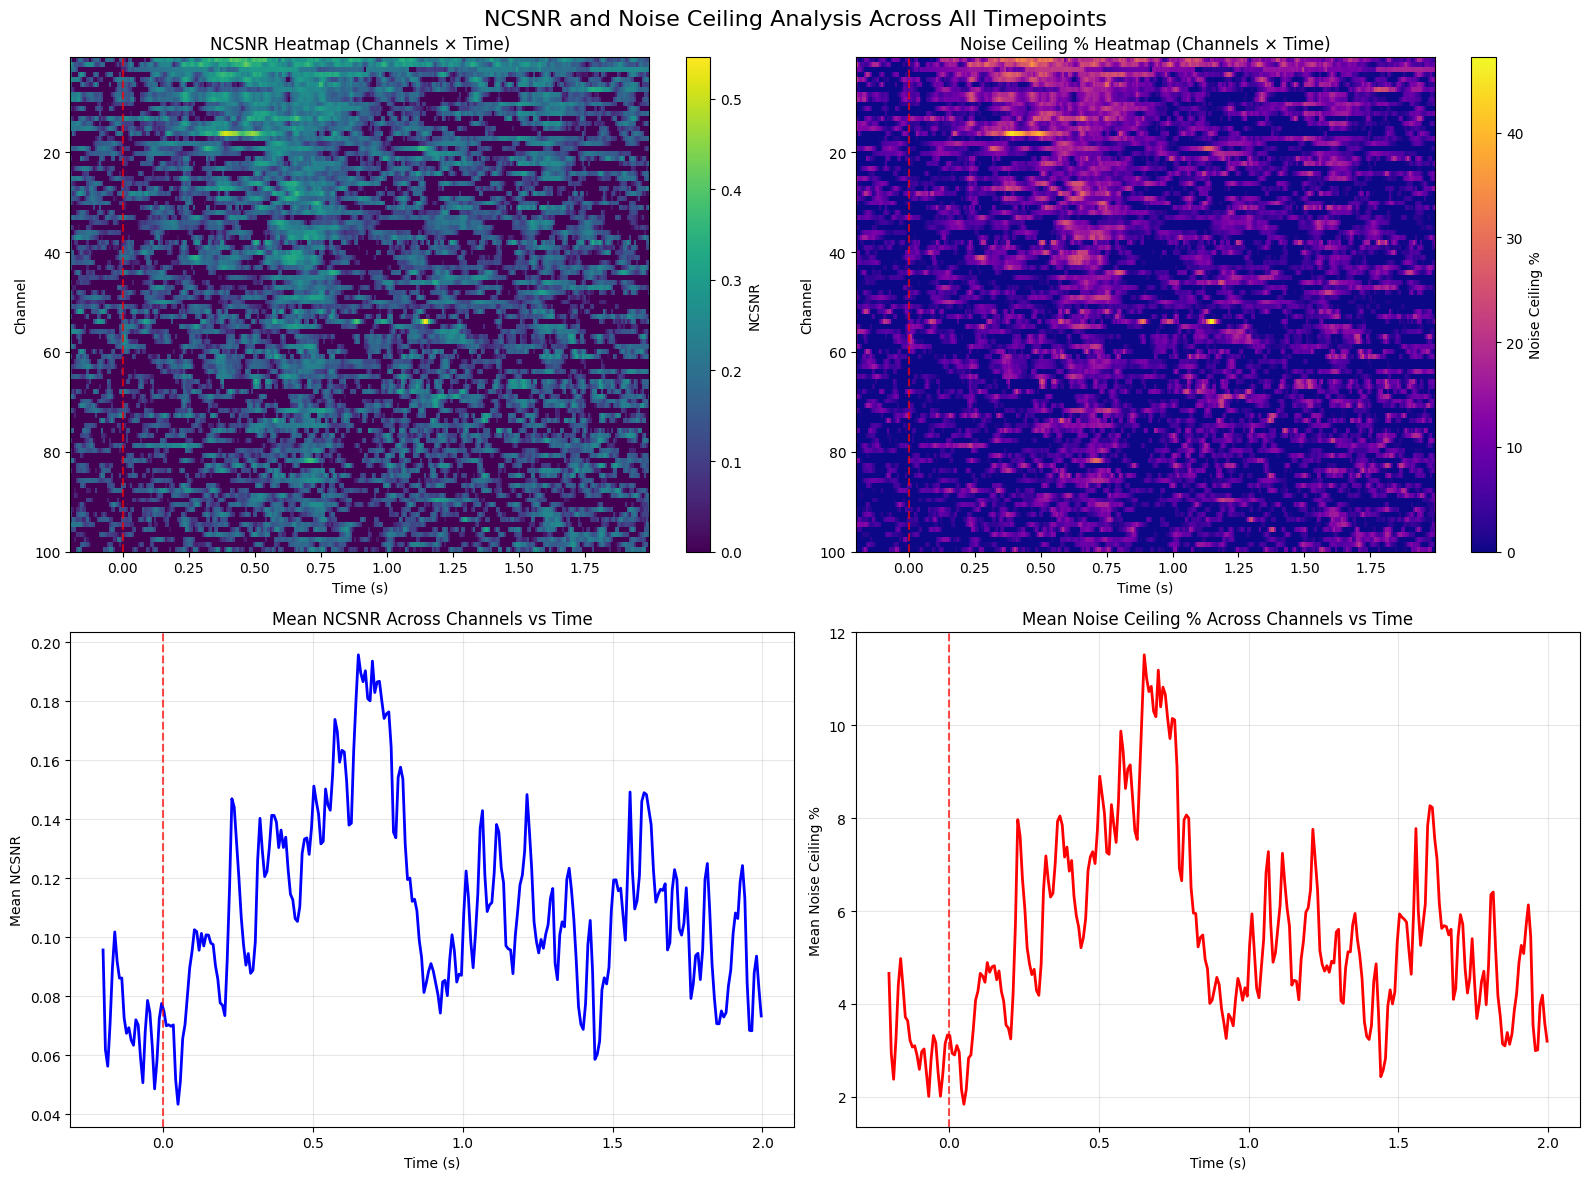


Summary Statistics:
Mean NCSNR across all channels and time: 0.109
Max NCSNR: 0.546
Mean Noise Ceiling across all channels and time: 5.4%
Max Noise Ceiling: 47.2%
Peak NCSNR time: 0.7ms
Peak NC time: 0.7ms


In [18]:
# The filtered_6_repeats has shape (channels, n_filtered_images, time, n_repeats)
# We need to transpose it to (conditions, channels, trials, timepoints) for the noise ceiling function
print(f"Original filtered data shape: {filtered_3_repeats.shape}")
window = np.arange(0,141)
# Transpose from (channels, images, time, repeats) to (images, channels, repeats, time)
data_rep = filtered_3_repeats.transpose(1, 0, 3, 2)
data_slim = data_rep[:,:,:]
print(f"Transposed data shape: {data_slim.shape}")
print(f"Shape interpretation: ({data_slim.shape[0]} conditions/images, {data_slim.shape[1]} channels, {data_slim.shape[2]} trials/repeats, {data_slim.shape[3]} timepoints)")

# Compute NCSNR for all timepoints
ncsnr_all, nc_all = compute_ncsnr_all_timepoints(data_slim, time)

rankings = np.flip(np.argsort(ncsnr_all.mean(1)))
# Visualize the results
ncsnr_figs(ncsnr_all[rankings[:100]], nc_all[rankings[:100]], time)